# Multi-Omics Gene Network Embedding

1. **Build gene interaction networks** from p-value tables (one CSV per omics type / cancer type).
2. **Convert** each network into a DGL graph dataset (`dataset.Dataset`).
3. **Train** a graph neural network (TAGConv by default; GCN / GraphSAGE / GAT are also available in `model.py`) per combination, using the hidden layer activations as node embeddings.
4. **Evaluate & visualize** the embeddings (t-SNE, PCA, cosine-similarity heatmaps, silhouette / Davies–Bouldin scores).
5. **Explore** the resulting gene embeddings (nearest-neighbor lookup, export for Cytoscape / Neo4j).

In [29]:
import os
import sys

PROJECT_ROOT = os.path.abspath('.')  # <- change if this notebook lives elsewhere
PACKAGE_DIR = os.path.join(PROJECT_ROOT, 'src')

assert os.path.isdir(PACKAGE_DIR), f"Can't find omics_embedding package at {PACKAGE_DIR}"
sys.path.insert(0, PACKAGE_DIR)

import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import dataset
import model
import network
import train
import utils
import dgl

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

CLUSTER_COLORS = {
    0: '#0077B6',   1: '#0000FF',   2: '#00B4D8',   3: '#48EAC4',
    4: '#F1C0E8',   5: '#B9FBC0',   6: '#32CD32',   7: '#bee1e6',
    8: '#8A2BE2',   9: '#E377C2',  10: '#8EECF5',  11: '#A3C4F3',
    12: '#FFB347', 13: '#FFD700',  14: '#FF69B4',  15: '#CD5C5C',
    16: '#7FFFD4', 17: '#FF7F50',  18: '#C71585',  19: '#20B2AA',
    20: '#6A5ACD', 21: '#40E0D0',  22: '#FF8C00',  23: '#DC143C',
    24: '#9ACD32'
}



CLUSTER_COLORS_OMICS = {
    0: '#D62728',  1: '#1F77B4',  2: '#2CA02C',  3: '#9467BD'
}


Using device: cpu


## 1. Configuration 

In [ ]:
# --- Data selection -----------------------------------------------------
DATA_DIR = '../data/omics'          # root folder holding data/omics/<omics>/<cancer>.csv
OMICS = 'mf'               # one of: 'cna', 'ge', 'meth', 'mf'
CANCER = 'KIRC'            # e.g. 'KIRC', 'BRCA', 'READ', 'PRAD', ...
P_VALUE_THRESHOLD = 0.05

ALL_OMICS_TYPES = sorted(['cna'])
ALL_CANCER_TYPES = sorted([
    'KIRC', 'BRCA'
])

# ALL_OMICS_TYPES = sorted(['cna', 'ge', 'meth', 'mf'])
# ALL_CANCER_TYPES = sorted([
#     'KIRC', 'BRCA', 'READ', 'PRAD', 'STAD', 'HNSC', 'LUAD',
#     'THCA', 'BLCA', 'ESCA', 'LIHC', 'UCEC', 'COAD', 'LUSC', 'CESC', 'KIRP'
# ])

hyperparams = {
    'num_epochs': 200,
    'in_feats': 1,      
    'out_feats': 16,   
    'num_layers': 4,
    'num_heads': 2,     
    'lr': 1e-3,
    'batch_size': 1,
    'device': device,
}
hyperparams

{'num_epochs': 100,
 'in_feats': 1,
 'out_feats': 16,
 'num_layers': 4,
 'num_heads': 2,
 'lr': 0.001,
 'batch_size': 1,
 'device': device(type='cpu')}

In [31]:
REAL_DATA_ROOT = os.path.abspath(os.path.join(DATA_DIR, os.pardir))
LOCAL_DATA_LINK = os.path.abspath('../data')

if os.path.isdir(os.path.join(LOCAL_DATA_LINK, 'omics')):
    print(f'{LOCAL_DATA_LINK}/omics already exists, leaving it as-is.')
elif os.path.exists(LOCAL_DATA_LINK):
    raise RuntimeError(
        f"'{LOCAL_DATA_LINK}' exists but has no 'omics' subfolder -- "
        f"move/rename it, or point DATA_DIR at wherever it actually lives."
    )
else:
    os.symlink(REAL_DATA_ROOT, LOCAL_DATA_LINK)
    print(f'Symlinked {LOCAL_DATA_LINK} -> {REAL_DATA_ROOT}')

assert os.path.isdir(os.path.join('data', 'omics')), (
    "Still can't find data/omics -- double check DATA_DIR and that the CSVs "
    "actually live under <DATA_DIR parent>/omics/<omics>/<cancer>.csv"
)
print('Sample contents:', os.listdir(os.path.join('data', 'omics'))[:10])

/Users/ericsali/Documents/2024_Winter/Project_gnn/reactome_markers/gnn_pathways/ACGNN_data/data/omics already exists, leaving it as-is.
Sample contents: ['.DS_Store', 'mf', 'meth', 'cna', 'ge']


## 2. Build the gene interaction networks 

In [32]:
graphs = utils.create_embedding_with_genes(
    p_value=P_VALUE_THRESHOLD,
    save=True,
    data_dir=DATA_DIR,
    omics_types=ALL_OMICS_TYPES,
    cancer_types=ALL_CANCER_TYPES,
)

print(f"\nBuilt {len(graphs)} / {len(ALL_OMICS_TYPES) * len(ALL_CANCER_TYPES)} combinations:")
summary_rows = []
for (omics, cancer), (graph_train, graph_test) in graphs.items():
    summary_rows.append({
        'omics': omics,
        'cancer': cancer,
        'train_nodes': graph_train.graph_nx.number_of_nodes(),
        'train_edges': graph_train.graph_nx.number_of_edges(),
        'test_nodes': graph_test.graph_nx.number_of_nodes(),
        'test_edges': graph_test.graph_nx.number_of_edges(),
    })
pd.DataFrame(summary_rows)


Processing: cna-BRCA
📊 [cna-BRCA] Total genes: 13639
📊 [cna-BRCA] Unique significance labels: [0, 1]
📊 [cna-BRCA] Significance distribution:
    significance=0: 1834 (13.45%)
    significance=1: 11805 (86.55%)
🔀 Using stratified 80/20 split for cna-BRCA

========== GENES TRAIN SIGNIFICANCE ==========
shape: (10911, 4)
columns: ['GeneA', 'GeneB', 'p_value', 'significance']
dtype: int64
unique:
significance
1    9444
0    1467
Name: count, dtype: int64
values:
[1 0]
          GeneA    GeneB  significance
3165       AGER     CTSK             1
6673       CD36    FFAR1             1
11110     AKAP1   AFG3L2             1
1039     ACTR1A  ANAPC10             1
3825        KDR      KDR             1
12004      ADAR    IFNA1             1
2620       AAAS     CDK6             1
7194     CAMK2A    MAPK1             1
5127       AGO3    ASF1A             1
12192      AKT2      CAT             1
13450      AGO2    APH1B             1
12007      BST2    IFNA1             1
10520     CPSF1    CPSF

,omics,cancer,train_nodes,train_edges,test_nodes,test_edges
0,cna,BRCA,2349,10911,1619,2728
1,cna,KIRC,2352,10911,1567,2728


## 3. Load each combination as a DGL dataset

`dataset.Dataset` converts every cached `.pkl` networkx graph under `emb/raw` into a DGL graph (carrying the `weight` and `significance` node attributes) and caches it under `emb/processed`. We build one `Dataset` per successfully-built combination.

In [33]:
datasets = {}
for (omics, cancer) in graphs.keys():
    data_path_ = os.path.join(DATA_DIR, omics, cancer)
    ds = dataset.Dataset(data_path_)
    datasets[(omics, cancer)] = ds
    print(f"{omics}/{cancer}: {len(ds)} graph(s) -> {sorted(os.listdir(ds.save_dir))}")

self.save_dir------------------------------------- /Users/ericsali/Documents/2024_Winter/Project_gnn/reactome_markers/gnn_pathways/ACGNN_data/data/omics/cna/BRCA/emb/processed
self.raw_dir-------------------------------------- /Users/ericsali/Documents/2024_Winter/Project_gnn/reactome_markers/gnn_pathways/ACGNN_data/data/omics/cna/BRCA/emb/raw
graph_file---------------------------------------- emb_test.pkl
self.save_dir------------------------------------- /Users/ericsali/Documents/2024_Winter/Project_gnn/reactome_markers/gnn_pathways/ACGNN_data/data/omics/cna/BRCA/emb/processed
self.raw_dir-------------------------------------- /Users/ericsali/Documents/2024_Winter/Project_gnn/reactome_markers/gnn_pathways/ACGNN_data/data/omics/cna/BRCA/emb/raw
graph_file---------------------------------------- emb_train.pkl
cna/BRCA: 2 graph(s) -> ['emb_test.dgl', 'emb_train.dgl']
self.save_dir------------------------------------- /Users/ericsali/Documents/2024_Winter/Project_gnn/reactome_markers/gnn

mkdir: tmp: File exists
mkdir: tmp: File exists


In [34]:
from pathlib import Path

print("DATA_DIR:", DATA_DIR)
print("DATA_DIR absolute:", Path(DATA_DIR).resolve())

for omics, cancer in list(graphs.keys())[:5]:

    base = Path(DATA_DIR) / omics / cancer

    print("\n" + "=" * 60)
    print(f"{omics} / {cancer}")
    print("base :", base.resolve())
    print("exists:", base.exists())

    if base.exists():
        print("files:")
        for p in base.rglob("*"):
            print("  ", p)

DATA_DIR: ../data/omics
DATA_DIR absolute: /Users/ericsali/Documents/2024_Winter/Project_gnn/reactome_markers/gnn_pathways/ACGNN_data/data/omics

cna / BRCA
base : /Users/ericsali/Documents/2024_Winter/Project_gnn/reactome_markers/gnn_pathways/ACGNN_data/data/omics/cna/BRCA
exists: True
files:
   ../data/omics/cna/BRCA/.DS_Store
   ../data/omics/cna/BRCA/emb
   ../data/omics/cna/BRCA/tmp
   ../data/omics/cna/BRCA/emb/.DS_Store
   ../data/omics/cna/BRCA/emb/models
   ../data/omics/cna/BRCA/emb/processed
   ../data/omics/cna/BRCA/emb/raw
   ../data/omics/cna/BRCA/emb/models/model_dim16_lay3_epo50.pth
   ../data/omics/cna/BRCA/emb/processed/emb_test.dgl
   ../data/omics/cna/BRCA/emb/processed/emb_train.dgl
   ../data/omics/cna/BRCA/emb/raw/emb_test.pkl
   ../data/omics/cna/BRCA/emb/raw/emb_train.pkl

cna / KIRC
base : /Users/ericsali/Documents/2024_Winter/Project_gnn/reactome_markers/gnn_pathways/ACGNN_data/data/omics/cna/KIRC
exists: True
files:
   ../data/omics/cna/KIRC/.DS_Store
   ../

## 4. Train embedding model

In [35]:

model_paths = {}

for (omics, cancer) in graphs.keys():

    print(f'=== Training {omics} / {cancer} ===')

    model_paths[(omics, cancer)] = train.train(
        hyperparams=hyperparams,
        data_path=DATA_DIR,
        plot=True,
        omics=omics,
        cancer=cancer,
    )

print(f'\nTrained {len(model_paths)} / {len(graphs)} combinations.')

mkdir: tmp: File exists


=== Training cna / BRCA ===

START STAGE-1 SIGNIFICANCE PRETRAINING
Omics       : cna
Cancer      : BRCA
Device      : cpu
Epochs      : 100
LR          : 0.001
Batch size  : 1
Out feats   : 16
Layers      : 4
Loss type   : focal
Decision thr: 0.2

self.save_dir------------------------------------- /Users/ericsali/Documents/2024_Winter/Project_gnn/reactome_markers/gnn_pathways/ACGNN_data/data/omics/cna/BRCA/emb/processed
self.raw_dir-------------------------------------- /Users/ericsali/Documents/2024_Winter/Project_gnn/reactome_markers/gnn_pathways/ACGNN_data/data/omics/cna/BRCA/emb/raw
graph_file---------------------------------------- emb_test.pkl
self.save_dir------------------------------------- /Users/ericsali/Documents/2024_Winter/Project_gnn/reactome_markers/gnn_pathways/ACGNN_data/data/omics/cna/BRCA/emb/processed
self.raw_dir-------------------------------------- /Users/ericsali/Documents/2024_Winter/Project_gnn/reactome_markers/gnn_pathways/ACGNN_data/data/omics/cna/BRCA/emb

Training:   2%|▏         | 2/100 [00:00<00:18,  5.33epoch/s, train_loss=0.3871, valid_loss=0.4277, train_f1=0.2542, valid_f1=0.2258]


*** BEST MODEL UPDATED ***
Epoch                : 1
Train Loss           : 0.529109
Valid Loss           : 0.650239
Valid F1 (thr=0.2)   : 0.225753
Best F1 across thresh: 0.225753 (thr=0.10)

----------------------------------------------------------------------
EPOCH 1 DIAGNOSTIC
----------------------------------------------------------------------
Train Loss : 0.529109
Valid Loss : 0.650239
Train F1   : 0.254181
Valid F1   : 0.225753
TP=206 | FP=1413 | FN=0 | TN=0
Probability min  : 0.678704
Probability max  : 0.952131
Probability mean : 0.761793
----------------------------------------------------------------------
threshold=0.10 | true_pos=206 | true_neg=1413 | pred_pos=1619 | pred_neg=0 | F1=0.2258
threshold=0.20 | true_pos=206 | true_neg=1413 | pred_pos=1619 | pred_neg=0 | F1=0.2258
threshold=0.30 | true_pos=206 | true_neg=1413 | pred_pos=1619 | pred_neg=0 | F1=0.2258
threshold=0.40 | true_pos=206 | true_neg=1413 | pred_pos=1619 | pred_neg=0 | F1=0.2258
threshold=0.50 | true_po

Training:   4%|▍         | 4/100 [00:00<00:16,  5.75epoch/s, train_loss=0.2031, valid_loss=0.1692, train_f1=0.2542, valid_f1=0.2258]

...


*** BEST MODEL UPDATED ***
Epoch                : 84
Train Loss           : 0.104934
Valid Loss           : 0.109478
Valid F1 (thr=0.2)   : 0.353498
Best F1 across thresh: 0.358628 (thr=0.30)

*** BEST MODEL UPDATED ***
Epoch                : 85
Train Loss           : 0.104929
Valid Loss           : 0.109459
Valid F1 (thr=0.2)   : 0.353498
Best F1 across thresh: 0.358628 (thr=0.30)


Training:  91%|█████████ | 91/100 [00:13<00:01,  6.98epoch/s, train_loss=0.1049, valid_loss=0.1102, train_f1=0.3615, valid_f1=0.3537]


----------------------------------------------------------------------
EPOCH 90 DIAGNOSTIC
----------------------------------------------------------------------
Train Loss : 0.104894
Valid Loss : 0.110042
Train F1   : 0.361546
Valid F1   : 0.353498
TP=336 | FP=1229 | FN=0 | TN=2
Probability min  : 0.173195
Probability max  : 0.393635
Probability mean : 0.332860
----------------------------------------------------------------------
threshold=0.10 | true_pos=336 | true_neg=1231 | pred_pos=1567 | pred_neg=0 | F1=0.3531
threshold=0.20 | true_pos=336 | true_neg=1231 | pred_pos=1565 | pred_neg=2 | F1=0.3535
threshold=0.30 | true_pos=336 | true_neg=1231 | pred_pos=1412 | pred_neg=155 | F1=0.3570
threshold=0.40 | true_pos=336 | true_neg=1231 | pred_pos=0 | pred_neg=1567 | F1=0.0000
threshold=0.50 | true_pos=336 | true_neg=1231 | pred_pos=0 | pred_neg=1567 | F1=0.0000
threshold=0.55 | true_pos=336 | true_neg=1231 | pred_pos=0 | pred_neg=1567 | F1=0.0000
threshold=0.60 | true_pos=336 | true_ne

Training: 100%|██████████| 100/100 [00:14<00:00,  6.75epoch/s, train_loss=0.1048, valid_loss=0.1102, train_f1=0.3615, valid_f1=0.3537]



----------------------------------------------------------------------
EPOCH 100 DIAGNOSTIC
----------------------------------------------------------------------
Train Loss : 0.104838
Valid Loss : 0.110162
Train F1   : 0.361546
Valid F1   : 0.353684
TP=336 | FP=1228 | FN=0 | TN=3
Probability min  : 0.173343
Probability max  : 0.396110
Probability mean : 0.332084
----------------------------------------------------------------------
threshold=0.10 | true_pos=336 | true_neg=1231 | pred_pos=1567 | pred_neg=0 | F1=0.3531
threshold=0.20 | true_pos=336 | true_neg=1231 | pred_pos=1564 | pred_neg=3 | F1=0.3537
threshold=0.30 | true_pos=336 | true_neg=1231 | pred_pos=1404 | pred_neg=163 | F1=0.3540
threshold=0.40 | true_pos=336 | true_neg=1231 | pred_pos=0 | pred_neg=1567 | F1=0.0000
threshold=0.50 | true_pos=336 | true_neg=1231 | pred_pos=0 | pred_neg=1567 | F1=0.0000
threshold=0.55 | true_pos=336 | true_neg=1231 | pred_pos=0 | pred_neg=1567 | F1=0.0000
threshold=0.60 | true_pos=336 | true_n

## 5. Inspect the training curves & embedding plots

Showing plots for ('cna', 'BRCA')


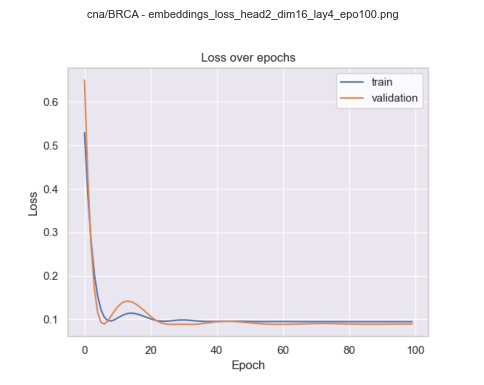

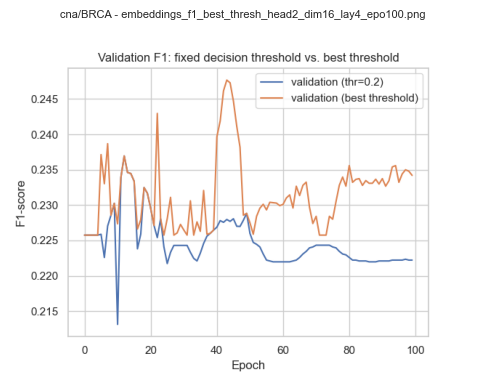

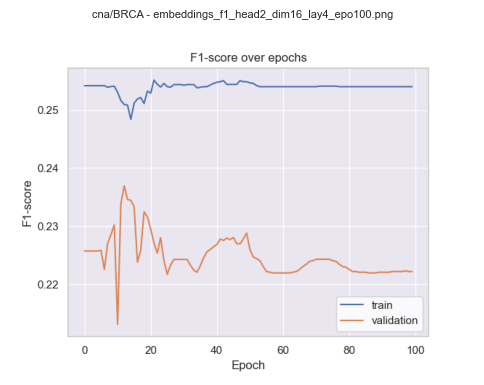

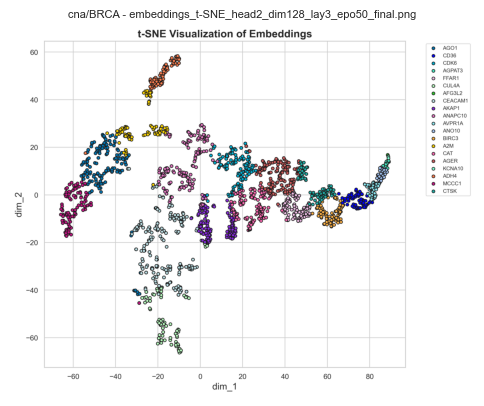

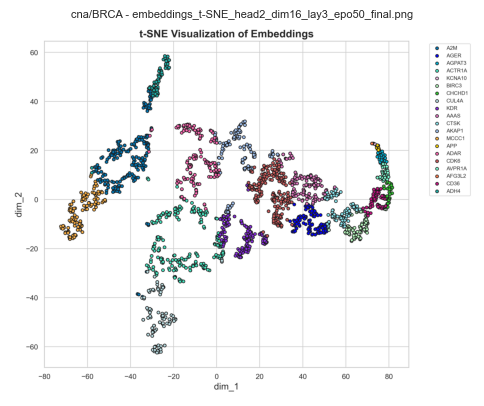

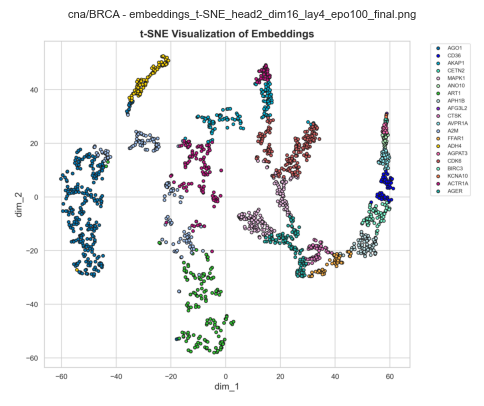

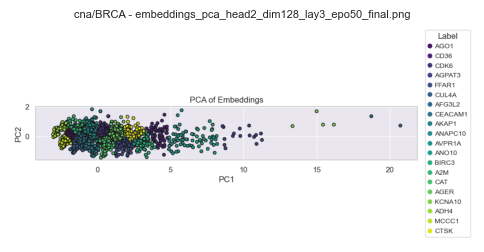

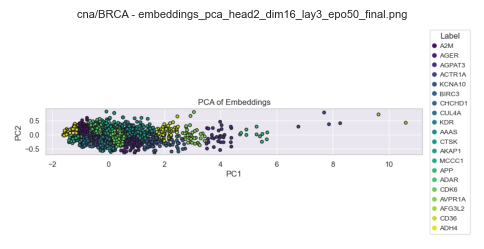

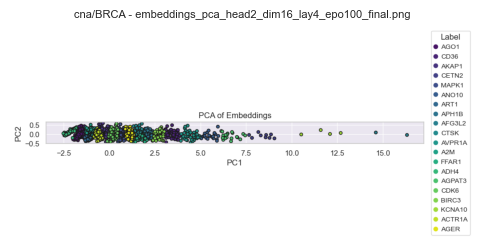

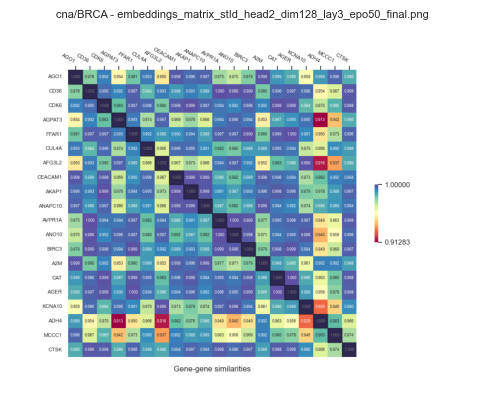

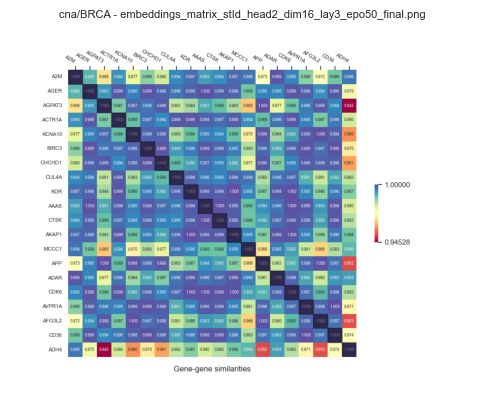

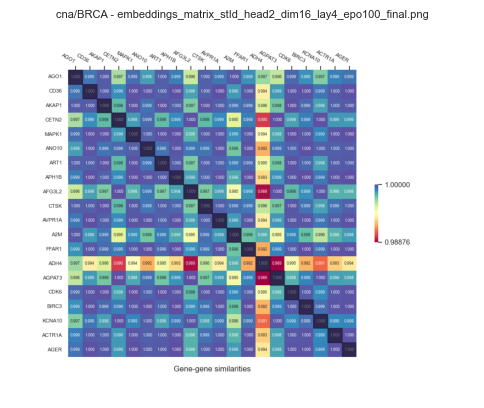

In [36]:
import glob

def show_combo_plots(omics, cancer, hyperparams):
    results_path = os.path.join('results/multiomics_meth/node_embeddings', omics, cancer)
    suffixes = [
        f'embeddings_loss_*dim{hyperparams["out_feats"]}_lay{hyperparams["num_layers"]}_epo{hyperparams["num_epochs"]}.png',
        f'embeddings_f1_*dim{hyperparams["out_feats"]}_lay{hyperparams["num_layers"]}_epo{hyperparams["num_epochs"]}.png',
        'embeddings_t-SNE_*_final.png',
        'embeddings_pca_*_final.png',
        'embeddings_matrix_stId_*_final.png',
    ]
    for suffix in suffixes:
        for path in sorted(glob.glob(os.path.join(results_path, suffix))):
            img = plt.imread(path)
            plt.figure(figsize=(6, 6))
            plt.imshow(img)
            plt.axis('off')
            plt.title(f'{omics}/{cancer} - {os.path.basename(path)}', fontsize=8)
            plt.show()

# Example: show plots for the first successfully trained combination
if model_paths:
    example_combo = next(iter(model_paths))
    print('Showing plots for', example_combo)
    show_combo_plots(*example_combo, hyperparams)

## 6. Load the exported gene embeddings

In [37]:
embedding_frames = {}
for (omics, cancer) in model_paths.keys():
    csv_candidates = sorted(glob.glob(os.path.join(
        DATA_DIR, omics, cancer,
        f'embeddings_lr{hyperparams["lr"]}_dim{hyperparams["out_feats"]}_lay{hyperparams["num_layers"]}_epo{hyperparams["num_epochs"]}_final.csv'
    )))
    if not csv_candidates:
        print(f'No embeddings CSV found for {omics}/{cancer}')
        continue
    embedding_frames[(omics, cancer)] = pd.read_csv(csv_candidates[-1], index_col='stId')

print(f'Loaded embeddings for {len(embedding_frames)} combinations.')
{k: v.shape for k, v in embedding_frames.items()}

No embeddings CSV found for cna/BRCA
No embeddings CSV found for cna/KIRC
Loaded embeddings for 0 combinations.


{}

## 7. Embeddings cosine-similarity: nearest neighbors for a gene

In [38]:
from sklearn.metrics.pairwise import cosine_similarity

EXAMPLE_COMBO = next(iter(embedding_frames)) if embedding_frames else None
TOP_K = 10

if EXAMPLE_COMBO is not None:
    emb_df = embedding_frames[EXAMPLE_COMBO]
    QUERY_STID = emb_df.index[0]  # <- replace with a specific stId of interest

    vectors = emb_df.values
    sims = cosine_similarity(emb_df.loc[[QUERY_STID]].values, vectors)[0]
    neighbors = (
        pd.Series(sims, index=emb_df.index)
        .drop(index=QUERY_STID)
        .sort_values(ascending=False)
        .head(TOP_K)
    )
    print(f'{EXAMPLE_COMBO}: top {TOP_K} genes most similar to {QUERY_STID}')
    display(neighbors)
else:
    print('No embeddings loaded yet.')

No embeddings loaded yet.


In [39]:
from sklearn.cluster import KMeans

cytoscape_paths = {}
for (omics, cancer), emb_df in embedding_frames.items():
    n_clusters = min(10, len(emb_df))
    if n_clusters < 2:
        print(f'Skipping {omics}/{cancer}: not enough genes to cluster')
        continue
    cluster_labels = KMeans(n_clusters=n_clusters, random_state=42, n_init=10).fit_predict(emb_df.values)
    out_path = os.path.join(DATA_DIR, omics, cancer, 'embeddings_cytoscape.csv')
    train.export_to_cytoscape(emb_df.values, cluster_labels, list(emb_df.index), out_path)
    cytoscape_paths[(omics, cancer)] = out_path

cytoscape_paths

{}